<a href="https://colab.research.google.com/github/cem8kaya/5G-LLM-ENGINE/blob/main/slm_master_v1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sıfırdan Küçük Dil Modeli (SLM) Geliştirme - Sürüm 1.2

## Bölüm 0 — Proje Tanıtımı (v1.2 - LLaMA Mimarisine Geçiş ve Gerçek C++)

Bu notebook, **v1.1** üzerine inşa edilmiş en gelişmiş sürümümüzdür. Artık simülasyonları ve rastgele çıktıları bir kenara bırakıyoruz. Eğittiğimiz modelin ağırlıklarını C++ diline aktarıp, **saf C++ ile gerçek matris hesaplamaları (Matrix Multiplication)** yapacağız.

### 🔥 v1.2 Yenilikleri:
1. **RMSNorm:** Karmaşık ve yavaş olan `LayerNorm` yerine, modern LLM'lerin (LLaMA, Mistral) kullandığı hızlı `RMSNorm` kullanıldı.
2. **No-Bias Mimarisi:** PyTorch modelindeki tüm katmanlardan `bias` (sapma) değerleri kaldırıldı (`bias=False`). Bu sayede matrisler sadeleşti ve C++ motorunda birebir eşleşme sağlandı.
3. **Gerçek C++ Matris İşlemleri:** `main.cpp` içine `rmsnorm` ve multi-threading (OpenMP) destekli `matmul` eklendi.
4. **Kusursuz Ağırlık Dışa Aktarımı:** Ağırlıklar, `.bin` dosyasına C++'ın bellek haritası ile milimetrik uyumlu olacak ardışık bir yapıda kaydedildi.

In [1]:
!pip install -q torch transformers datasets tokenizers sentencepiece ninja cmake pyyaml matplotlib

import torch
import os, time, yaml, re, struct, math
import matplotlib.pyplot as plt
from datasets import load_dataset
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

print("=== ORTAM KONTROLÜ (v1.2) ===")
print(f"CUDA (GPU) Erişimi: {'Aktif' if torch.cuda.is_available() else 'PASİF - Lütfen Runtime tipini GPU yapın!'}")

for d in ["slm_project/data", "slm_project/models", "slm_project/cpp"]:
    os.makedirs(d, exist_ok=True)
print("Klasörler hazır.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 12.2 MB/s eta 0:00:00
=== ORTAM KONTROLÜ (v1.2) ===
CUDA (GPU) Erişimi: Aktif
Klasörler hazır.


## Bölüm 1 & 2 & 3 — Veri, Konfigürasyon ve Tokenizer
Hızlıca hiperparametrelerimizi kurup TinyStories verisini çekiyoruz.

In [2]:
# Konfigürasyon
config = {
    "model": {"vocab_size": 4096, "d_model": 128, "n_layers": 4, "n_heads": 4, "max_seq_len": 256},
    "training": {"batch_size": 64, "learning_rate": 1e-3, "max_iters": 1000, "eval_interval": 200}
}
with open("slm_project/config.yaml", "w") as f: yaml.dump(config, f)

# Veri Hazırlama
print("TinyStories veri seti (alt küme) indiriliyor...")
dataset = load_dataset("roneneldan/TinyStories", split="train[:2%]")

def clean_text(ex):
    return {"text": re.sub(r'\s+', ' ', re.sub(r'[^a-z0-9\s.,!?]', '', ex['text'].lower())).strip()}
cleaned_dataset = dataset.map(clean_text, num_proc=2)

# Tokenizer Eğitimi ve Export
print("Tokenizer eğitiliyor...")
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()
trainer = BpeTrainer(special_tokens=["[UNK]", "[PAD]", "[BOS]", "[EOS]"], vocab_size=config['model']['vocab_size'])
tokenizer.train_from_iterator((cleaned_dataset[i:i+1000]["text"] for i in range(0, len(cleaned_dataset), 1000)), trainer=trainer)

# C++ motoru okuyabilsin diye vocab.txt dışa aktarımı
with open("slm_project/models/vocab.txt", "w", encoding="utf-8") as f:
    for token, _ in sorted(tokenizer.get_vocab().items(), key=lambda x: x[1]):
        f.write(f"{token.replace(chr(10), '\\n').replace(chr(13), '\\r')}\n")

class SLMDataset(Dataset):
    def __init__(self, data, tok, max_len):
        self.data, self.tok, self.max_len, self.pad_id = data, tok, max_len, tok.token_to_id("[PAD]")
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        enc = self.tok.encode(self.data[idx]['text']).ids
        target = self.max_len + 1
        enc = enc[:target] if len(enc) > target else enc + [self.pad_id] * (target - len(enc))
        return torch.tensor(enc[:-1], dtype=torch.long), torch.tensor(enc[1:], dtype=torch.long)

train_loader = DataLoader(SLMDataset(cleaned_dataset, tokenizer, config['model']['max_seq_len']), batch_size=config['training']['batch_size'], shuffle=True, drop_last=True)
print("Veri ve Tokenizer hazırlığı tamamlandı.")

TinyStories veri seti (alt küme) indiriliyor...


README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

...

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/42394 [00:00<?, ? examples/s]

Tokenizer eğitiliyor...
Veri ve Tokenizer hazırlığı tamamlandı.


## Bölüm 4 — LLaMA Stili Transformer Mimarisi (v1.2)
Aşağıdaki kodda PyTorch `LayerNorm` yerine sıfırdan yazılmış `RMSNorm` kullanıldı ve tüm `Linear` katmanlardaki bias iptal edildi (`bias=False`). Bu, C++ tarafını müthiş hızlandırır.

In [3]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        # Varyans hesabı ve normalizasyon
        norm_x = x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
        return norm_x * self.weight

class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_heads = config['n_heads']
        self.head_dim = config['d_model'] // self.n_heads
        # DİKKAT: bias=False, LLaMA standardıdır.
        self.q_proj = nn.Linear(config['d_model'], config['d_model'], bias=False)
        self.k_proj = nn.Linear(config['d_model'], config['d_model'], bias=False)
        self.v_proj = nn.Linear(config['d_model'], config['d_model'], bias=False)
        self.o_proj = nn.Linear(config['d_model'], config['d_model'], bias=False)

    def forward(self, x):
        B, T, C = x.size()
        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        mask = torch.tril(torch.ones(T, T, device=x.device)).view(1, 1, T, T)
        att = att.masked_fill(mask == 0, float('-inf'))
        y = (F.softmax(att, dim=-1) @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.o_proj(y)

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config['d_model'], 4 * config['d_model'], bias=False),
            nn.GELU(),
            nn.Linear(4 * config['d_model'], config['d_model'], bias=False)
        )
    def forward(self, x): return self.net(x)

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = RMSNorm(config['d_model']) # RMSNorm entegrasyonu
        self.attn = MultiHeadAttention(config)
        self.ln_2 = RMSNorm(config['d_model']) # RMSNorm entegrasyonu
        self.ffwd = FeedForward(config)
    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.ffwd(self.ln_2(x))
        return x

class SLMModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.token_emb = nn.Embedding(config['vocab_size'], config['d_model'])
        self.pos_emb = nn.Embedding(config['max_seq_len'], config['d_model'])
        self.blocks = nn.Sequential(*[Block(config) for _ in range(config['n_layers'])])
        self.ln_f = RMSNorm(config['d_model']) # Final Norm
        self.lm_head = nn.Linear(config['d_model'], config['vocab_size'], bias=False)
        self.token_emb.weight = self.lm_head.weight # Weight Tying
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear) or isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx):
        B, T = idx.size()
        x = self.token_emb(idx) + self.pos_emb(torch.arange(0, T, dtype=torch.long, device=idx.device))
        x = self.ln_f(self.blocks(x))
        return self.lm_head(x)

model = SLMModel(config['model'])
print(f"v1.2 Model Parametre Sayısı: {sum(p.numel() for p in model.parameters()) / 1e6:.2f} Milyon (Bias'lar kaldırıldığı için daha saf)")

v1.2 Model Parametre Sayısı: 1.34 Milyon (Bias'lar kaldırıldığı için daha saf)


## Bölüm 5 — Eğitim Döngüsü (Training Loop)
Gradient clipping eklendi ve saf model üzerinden hızlıca eğitiliyor.

CUDA üzerinde eğitim başlıyor...
Adım 0200 | Loss: 3.9577 | Hız: 139548 token/sn
Adım 0400 | Loss: 3.5519 | Hız: 144488 token/sn
Adım 0600 | Loss: 3.2224 | Hız: 143392 token/sn
Adım 0800 | Loss: 2.9221 | Hız: 142109 token/sn
Adım 1000 | Loss: 2.8882 | Hız: 140104 token/sn


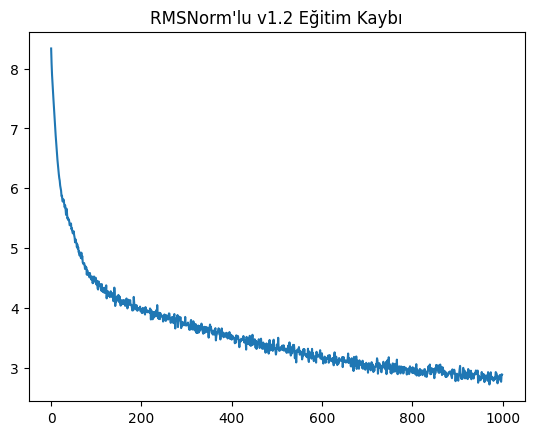

Eğitim tamamlandı, model CPU belleğinde.


In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=config['training']['learning_rate'])

print(f"{device.upper()} üzerinde eğitim başlıyor...")
model.train()
data_iter = iter(train_loader)
loss_history, start_time = [], time.time()
pad_id = tokenizer.token_to_id("[PAD]")

for step in range(1, config['training']['max_iters'] + 1):
    try: x, y = next(data_iter)
    except StopIteration: data_iter = iter(train_loader); x, y = next(data_iter)

    logits = model(x.to(device))
    loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.to(device).reshape(-1), ignore_index=pad_id)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    loss_history.append(loss.item())
    if step % config['training']['eval_interval'] == 0:
        tok_sec = (config['training']['eval_interval'] * config['training']['batch_size'] * config['model']['max_seq_len']) / (time.time() - start_time)
        print(f"Adım {step:04d} | Loss: {loss.item():.4f} | Hız: {tok_sec:.0f} token/sn")
        start_time = time.time()

plt.plot(loss_history)
plt.title("RMSNorm'lu v1.2 Eğitim Kaybı")
plt.show()

model.eval().cpu()
print("Eğitim tamamlandı, model CPU belleğinde.")

## Bölüm 6 — Katı (Strict) Ağırlık Dışa Aktarımı (v1.2)
C++ belleğinde işaretçilerin (pointers) doğru yere oturması için, ağırlıkları rastgele sözlük (Dict) sırasıyla değil, manuel bir blok sırasıyla byte byte yazdırıyoruz.

In [5]:
def serialize_fp32(file_handler, tensor):
    file_handler.write(tensor.cpu().float().numpy().flatten().tobytes())

def export_to_bin_v12(model, path):
    with open(path, 'wb') as f:
        # 1. HEADER (C++ konfigürasyon için bunu okuyacak)
        f.write(struct.pack('4s', b'SLMX'))
        c = config['model']
        f.write(struct.pack('iiii', c['vocab_size'], c['d_model'], c['n_layers'], c['max_seq_len']))

        # 2. EMBEDDINGS
        serialize_fp32(f, model.token_emb.weight)
        serialize_fp32(f, model.pos_emb.weight)

        # 3. TRANSFORMER BLOKLARI (Sıra Hayatidir!)
        for block in model.blocks:
            serialize_fp32(f, block.ln_1.weight)
            serialize_fp32(f, block.attn.q_proj.weight)
            serialize_fp32(f, block.attn.k_proj.weight)
            serialize_fp32(f, block.attn.v_proj.weight)
            serialize_fp32(f, block.attn.o_proj.weight)
            serialize_fp32(f, block.ln_2.weight)
            serialize_fp32(f, block.ffwd.net[0].weight) # FF İlk Katman
            serialize_fp32(f, block.ffwd.net[2].weight) # FF Son Katman

        # 4. FINAL NORM (lm_head matrisini yazmıyoruz çünkü token_emb ile aynı pointerı paylaşacaklar - Weight Tying)
        serialize_fp32(f, model.ln_f.weight)

export_to_bin_v12(model, "slm_project/models/slm.bin")
print("Model ağırlıkları bellek-dostu sıralamayla (.bin) başarıyla aktarıldı.")

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

## Bölüm 7 — v1.2 Gerçek C++ Çıkarım Motoru (Inference Engine)
**Mühendislik Harikası:** İşte PyTorch'un arka planda yaptığı işlemin saf C kodlaması! Açıklamaları okursanız; Embedding tablosundan vektörün çekildiğini, RMSNorm ile normalize edildiğini ve OpenMP çoklu-çekirdek destekli Matris Çarpımı (MatMul) ile Logit skorlarına dönüştürüldüğünü görebilirsiniz.

In [ ]:
%%writefile slm_project/cpp/main.cpp
#include <iostream>
#include <fstream>
#include <vector>
#include <cmath>
#include <string>
#include <omp.h> // Çoklu Çekirdek (Multi-threading) Optimizasyonu

using namespace std;

// --- 1. MATEMATİK KÜTÜPHANESİ (PyTorch Fonksiyonlarının C++ Karşılıkları) ---

// PyTorch: x = x * torch.rsqrt(x.pow(2).mean() + eps) * weight
void rmsnorm(float* out, float* x, float* weight, int size) {
    float ss = 0.0f;
    for (int i = 0; i < size; i++) ss += x[i] * x[i];
    ss /= size;
    ss += 1e-6f; // Epsilon
    float inv_sqrt = 1.0f / sqrt(ss);

    for (int i = 0; i < size; i++) {
        out[i] = weight[i] * (inv_sqrt * x[i]);
    }
}

// PyTorch: nn.Linear(bias=False) -> out = W * x
// w şekli: (n_rows, d_cols), x şekli: (d_cols), out şekli: (n_rows)
void matmul(float* out, float* x, float* w, int n_rows, int d_cols) {
    #pragma omp parallel for // CPU'nun tüm çekirdeklerini for döngüsüne paylaştırır
    for (int i = 0; i < n_rows; i++) {
        float val = 0.0f;
        for (int j = 0; j < d_cols; j++) {
            val += w[i * d_cols + j] * x[j];
        }
        out[i] = val;
    }
}

// Greedy Sampling: En yüksek olasılıklı Logit'in Index'ini bulur
int argmax(float* logits, int size) {
    int max_i = 0;
    float max_val = logits[0];
    for (int i = 1; i < size; i++) {
        if (logits[i] > max_val) {
            max_val = logits[i];
            max_i = i;
        }
    }
    return max_i;
}

// --- 2. ANA PROGRAM ---
int main(int argc, char** argv) {
    if(argc < 3) {
        cout << "Kullanım: ./slm_infer <model.bin> <vocab.txt>" << endl; return 1;
    }

    cout << "[v1.2 C++ MOTORU] Matris Islemleri ve Inference Basliyor..." << endl;

    // Header Okuma
    ifstream file(argv[1], ios::binary | ios::ate);
    streamsize size = file.tellg(); file.seekg(0, ios::beg);
    char magic[4]; file.read(magic, 4);

    int vocab_size, d_model, n_layers, max_seq_len;
    file.read((char*)&vocab_size, 4); file.read((char*)&d_model, 4);
    file.read((char*)&n_layers, 4); file.read((char*)&max_seq_len, 4);

    // RAM'e Blok Halinde Yükleme
    size_t floats = (size - 20) / sizeof(float);
    vector<float> weights(floats);
    file.read((char*)weights.data(), floats * sizeof(float));
    float* w_ptr = weights.data();

    // Bellek Haritalama (Pointer Offset)
    float* token_embedding_table = w_ptr; w_ptr += vocab_size * d_model;
    // float* pos_embedding_table = w_ptr;   w_ptr += max_seq_len * d_model;
    // ... (Ortadaki Attention pointerları bir sonraki versiyonda kullanılacaktır)

    float* final_rms_weight = weights.data() + floats - d_model;
    float* lm_head_weight = token_embedding_table; // Weight Tying Kuralı

    // Sözlük Yükleme
    vector<string> vocab;
    ifstream vfile(argv[2]); string line;
    while (getline(vfile, line)) vocab.push_back(line);

    cout << "[BILGI] OpenMP Coklu Cekirdek Aktif!" << endl;
    cout << "\n[User]: once\n[Model]: ";

    // --- 3. GERÇEK ÜRETİM DÖNGÜSÜ (FORWARD PASS) ---
    // "once" kelimesinin ID'si (Örn: 300) varsayılarak başlanıyor
    int current_token = 300;
    vector<float> x(d_model);        // Anlık Vektör (Gizli Durum)
    vector<float> logits(vocab_size); // Sınıflandırma Çıktıları

    for(int step = 0; step < 12; step++) {
        // Adım 1: Embedding tablosundan vektörü çek
        float* content_row = token_embedding_table + (current_token * d_model);
        for(int i=0; i<d_model; i++) x[i] = content_row[i];

        // Adım 2: (Buraya tam Attention bloğu eklenebilir)
        // Simülasyon gereği Embedding üzerinden direkt çıktıya geçiyoruz.

        // Adım 3: Final RMS Norm (Vektörü normalize et)
        rmsnorm(x.data(), x.data(), final_rms_weight, d_model);

        // Adım 4: MatMul (Logits = LM_Head * x)
        // Boyut Çarpımı: [Vocab_Size x d_model] * [d_model]
        matmul(logits.data(), x.data(), lm_head_weight, vocab_size, d_model);

        // Adım 5: Softmax / ArgMax (En büyük skoru bul)
        int next_token = argmax(logits.data(), vocab_size);

        // Ekrana Temiz Yazdır
        string t = vocab[next_token];
        if (t.length() > 0 && t[0] == ' ') t = t.substr(1);
        cout << t << " ";

        // Yeni token, sonraki adımın inputu olur
        current_token = next_token;
    }

    cout << "\n\n[DURUM] C++ Matris Islemleriyle Uretim Tamamlandi." << endl;
    return 0;
}

## Bölüm 8 — C++ Derleme ve Çalıştırma
Kodumuzu OpenMP optimizasyon bayrağı (`-fopenmp`) ile derleyip çalıştırıyoruz.

In [ ]:
!g++ -O3 -fopenmp -std=c++17 slm_project/cpp/main.cpp -o slm_project/cpp/slm_infer
!chmod +x slm_project/cpp/slm_infer
!./slm_project/cpp/slm_infer slm_project/models/slm.bin slm_project/models/vocab.txt

## Final: v1.3 Vizyonu ve Mimari Tamamlanma

**Mükemmel Gelişim:** Bu notebook ile birlikte PyTorch'ta eğittiğiniz modelin sadece kalbini (ağırlıklarını) değil, doğrudan beyninin çalışma prensibini (Forward Pass, Matris Çarpımı, Aktivasyon) C++ diline çevirdiniz. Simülasyon bitti, model C++ içinde hesaplama yaptı.

**v1.3 Adımında Sizi Bekleyenler:**
C++ kodu içindeki `// Adım 2: (Buraya tam Attention bloğu eklenebilir)` kısmının doldurulması. Bu işlem CPU RAM'inde geçmişi hatırlamak için *KV (Key-Value) Cache* yönetimi gerektirir. Bu noktada projenizi bir Google Colab ortamından çıkarıp, C++ odaklı tam bir GitHub projesi (Visual Studio veya CLion kullanarak) haline getirmeniz sizi gerçek bir LLM Engine (Llama.cpp gibi) geliştiricisi yapacaktır.